# **Hedy - TU Wien Space Team - 2025**

Team: TUST\
Project: Lamarr \
Rocket: Hedy \
Launched on 12.10.2025 at EuRoC


## Installs

In this section all needed libraries are installed and the needed classes imported

In [ ]:
%pip install rocketpy

In [ ]:
%pip install CoolProp

In [24]:
import CoolProp.CoolProp as CP

from rocketpy import (
    CompareFlights,
    CylindricalTank,
    Environment,
    Flight,
    Fluid,
    FreeFormFins,
    LiquidMotor,
    MassFlowRateBasedTank,
    NoseCone,
    Parachute,
    Rocket,
    Tail,
)

## Configuration

The length unit chosen here is millimeters to keep the values more readable. If necessary, values should be converted accordingly.

In [37]:
# Rocket configuration data
env_config = {
    "date": (2025, 10, 12, 17, 00, 00),  # yyyy, mm, dd, hh, mm, ss    # preset
    "latitude": 39.39046096801758,  # Launch latitude             # preset
    "longitude": -8.288534164428711,  # Launch longitude            # preset
    "max_height": 9000,  # m                           # preset
    "timezone": "Europe/Lisbon",  # GMT+1                       # preset
}
motor_config = {
    "holddown_time": 1.4,  # s       # preset
    "nitrogen_tank": {
        "length": 235,  # mm      # measured
        "CG_lox": 2653,  # mm      # measured # CG lox nitrogen tank
        "CG_ethanol": 1450,  # mm      # measured # CG ethanol nitrogen tank
        "outer_diameter": 93,  # mm      # measured
        "volume": 1.2,  # l       # measured
        "massflow": 0.03,  # kg/s    # estimated
    },
    "ethanol_tank": {
        "length": 573,  # mm      # measured
        "CG": 852,  # mm      # measured
        "outer_diameter": 115,  # mm      # measured
        "volume": 5.27,  # l       # measured
        "massflow": 0.45,  # kg/s    # tested
    },
    "lox_tank": {
        "length": 573,  # mm      # measured
        "CG": 1960,  # mm      # measured
        "outer_diameter": 115,  # mm      # measured
        "volume": 5.27,  # l       # measured
        "massflow": 0.56,  # kg/s    # tested
    },
    "nozzle": {
        "diameter": 75,  # mm      # measured
        "position": -40,  # mm      # measured
    },
    "thrust": "../../data/rockets/tust/hedy_thrust_euroc_launch.csv",  # N       # measured
    "temperature": {
        "ethanol": 298.15,  # K       # preset (= 25°C)
        "lox": 93.15,  # K       # preset (= -180°C)
        "nitrogen": 298.15,  # K       # preset (= 25°C)
    },
    "pressure": {
        "ethanol": 3000000,  # Pa      # preset
        "lox": 3000000,  # Pa      # preset
        "nitrogen": 30000000,  # Pa      # preset
    },
}

rocket_config = {
    "total_weight": 17200,  # g       # weighed dry mass
    "total_length": 3707,  # mm      # measured
    "total_CG": 1813,  # mm      # measured
    "moment_of_intertia_Z": 0.0255,  # kg*m^2  # calculated
    "moment_of_intertia_XY": 16.8,  # kg*m^2  # calculated
    "nosecone": {
        "length": 561,  # mm      # measured    # 575 + 66 - 80 = 561
        "kind": "lv haack",
    },
    "railbuttons": {
        "upper": 1646,  # mm      # measured
        "lower": 305,  # mm      # measured
    },
    "tailcone": {
        "diameter": 108,  # mm      # measured
        "length": 245,  # mm      # measured
        "cylindrical_height": 35,  # mm      # measured
    },
    "rocket": {
        "thickness": 1.4,  # mm      # measured
        "diameter": 132.8,  # mm      # measured
    },
    "fins": {
        "name": "Biconvex-Freeform",
        "amount": 4,
        "position": 250,  # mm      # measured
        "shape_points": (
            (0, 0),
            (0.250, -0.012),
            (0.250, 0.108),
            (0.195, 0.108),
            (0, 0),
        ),  # m       # measured
    },
    "parachutes": {
        "main": {
            "cd_s": 6.911503837897546,  # calculated
            "trigger": 450,  # m               # preset
            "sampling_rate": 105,  # hz              # preset
            "lag": 4,  # s               # measured
            "noise": (0, 8.3, 0.5),  # (pa, pa, pa)    # preset
        },
        "drogue": {
            "cd_s": 0.5336875,
            "trigger": "apogee",  # m               # preset
            "sampling_rate": 105,  # hz              # preset
            "lag": 1,  # s               # measured
            "noise": (0, 8.3, 0.5),  # (pa, pa, pa)    # preset
        },
    },
}
flight_config = {
    "rail_length": 11,  # m       #Preset
    "inclination": 84,  # °       #Preset
    "heading": 184,  # °       #Preset
    "terminate_on_apogee": False,
}

## Environments Initialization




In this section the environments are initialized.
*   **envReanalysis**: environment with the weather data from the location and date of EuRoc'25


Fetching elevation from open-elevation.com for lat=39.39046096801758, lon=-8.288534164428711...
Elevation received: 160.0 m

Gravity Details

Acceleration of gravity at surface level:    9.7798 m/s²
Acceleration of gravity at   6.555 km (ASL): 9.7601 m/s²


Launch Site Details

Launch Date: 2025-10-12 16:00:00 UTC | 2025-10-12 17:00:00 Europe/Lisbon
Launch Site Latitude: 39.39046°
Launch Site Longitude: -8.28853°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 160.0 m


Atmospheric Model Details

Atmospheric Model Type: Reanalysis
Reanalysis Maximum Height: 6.555 km
Reanalysis Time Period: from 2025-10-12 15:00:00 to 2025-10-12 20:00:00 utc
Reanalysis Hour Interval: 1 hrs
Reanalysis Latitude Range: From 42.0° to 36.0°
Reanalysis Longitude Range: From -10.0° to -6.0°

Surface Atmospheric Conditions

Surface Wind Speed: 2.23 m/s
Surface Wind Direction: 67.67°
Surface Wind Heading: 247.67°
Surface Pr

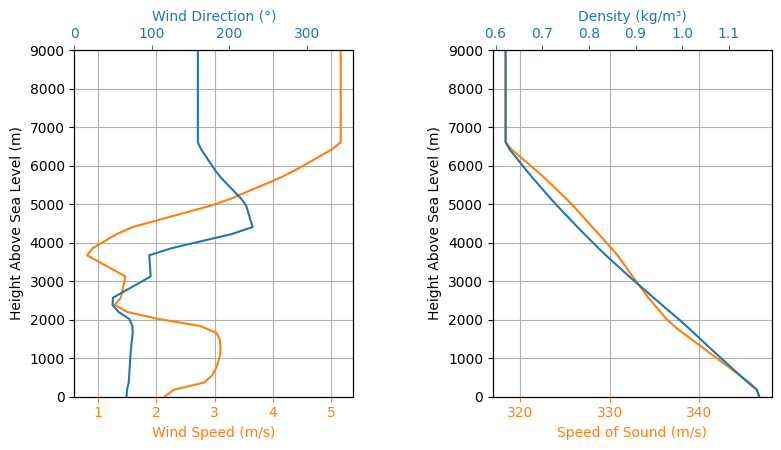

In [38]:
# Ponte de Sor: 39.12368, -8.03333
# Launch date: 12.10.2025, 17:00


latitude = env_config["latitude"]
longitude = env_config["longitude"]
timezone = env_config["timezone"]
date = env_config["date"]
max_height = env_config["max_height"]

# Environment based on weather data of the EuRoC 2025
envReanalysis = Environment(max_expected_height=max_height)

envReanalysis.set_location(latitude=latitude, longitude=longitude)
envReanalysis.set_elevation("Open-Elevation")
envReanalysis.set_date(date, timezone=timezone)

envReanalysis.set_atmospheric_model(
    type="Reanalysis",
    file="../../data/weather/hedy_euroc_2025_weather_data.nc",
    dictionary="ECMWF",
)
envReanalysis.info()

## Simulation

### Tanks / Engine



using ethanol burn time (9.225280880958138). LOX burntime is 10.662815399911576
Nozzle Details
Nozzle Radius: 0.0375 m

Motor Details
Total Burning Time: 7.825280880958138 s
Total Propellant Mass: 8.373 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 1363.917 m/s
Average Thrust: 1369.450 N
Maximum Thrust: 1561.34 N at 2.0 s after ignition.
Total Impulse: 10716.328 Ns



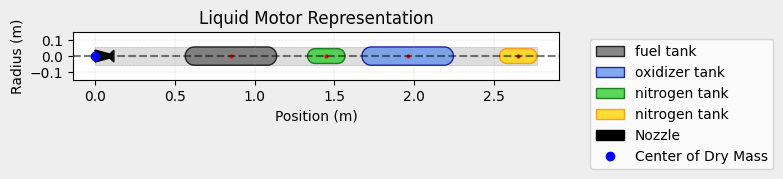

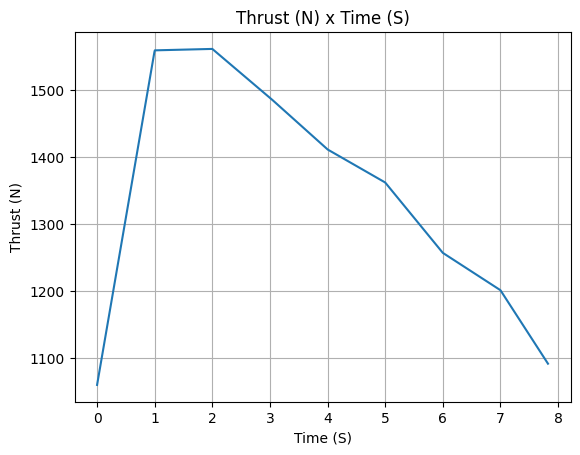

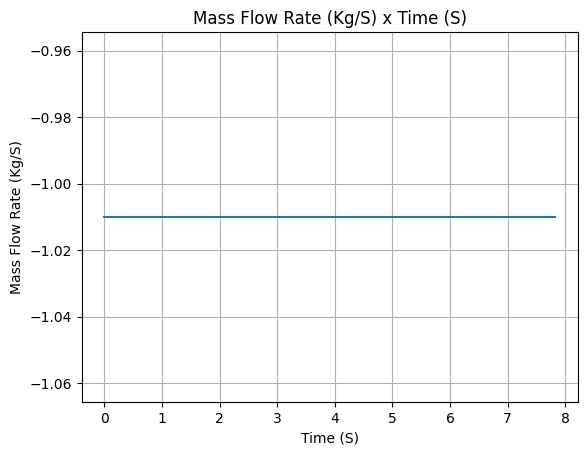

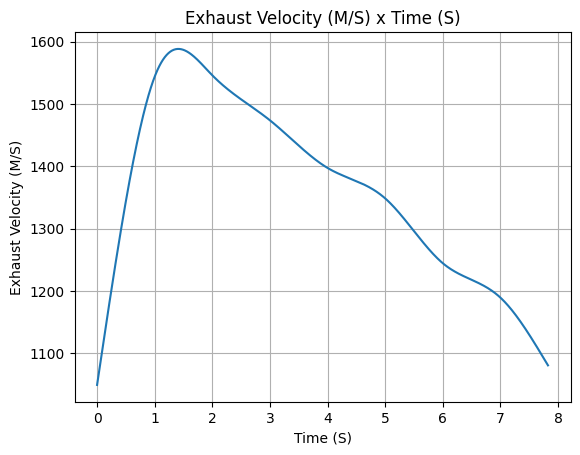

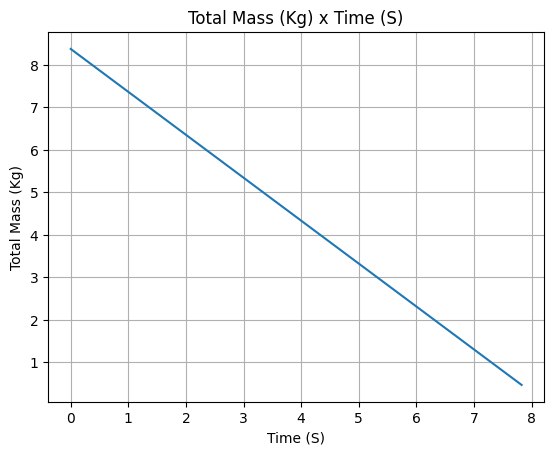

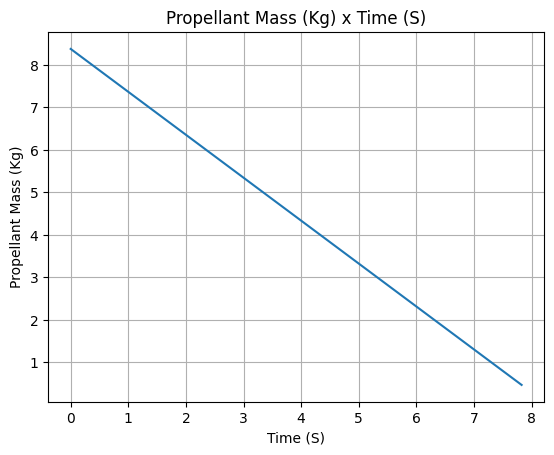

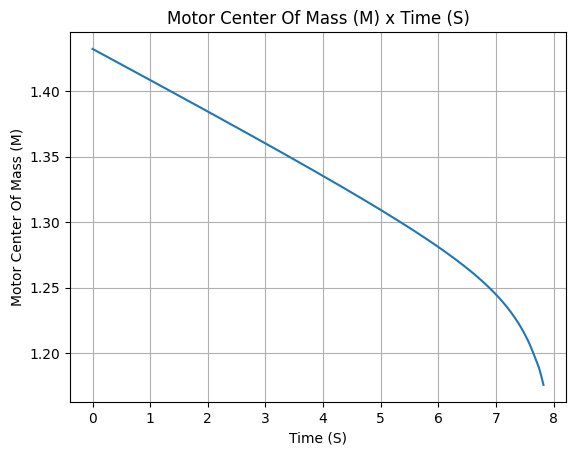

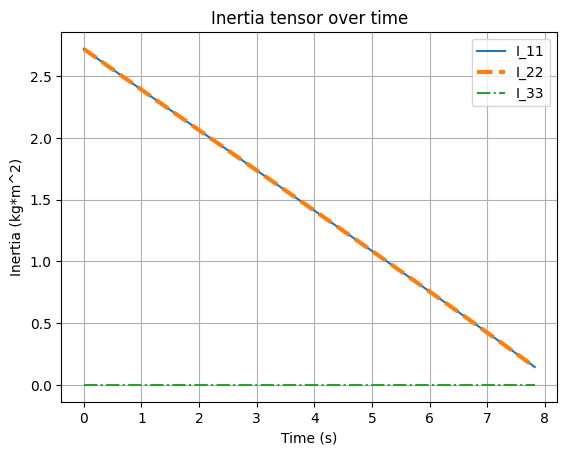

In [39]:
# holddown time
t_holddown = motor_config["holddown_time"]

# tank height
h_nitrogen_tank = motor_config["nitrogen_tank"]["length"] / 1000
h_ethanol_tank = motor_config["ethanol_tank"]["length"] / 1000
h_lox_tank = motor_config["lox_tank"]["length"] / 1000
# OuterDiameter
OD_nitrogen_tank = motor_config["nitrogen_tank"]["outer_diameter"] / 1000
OD_ethanol_tank = motor_config["ethanol_tank"]["outer_diameter"] / 1000
OD_lox_tank = motor_config["lox_tank"]["outer_diameter"] / 1000
# volume
v_nitrogen_tank = motor_config["nitrogen_tank"]["volume"] / 1000
v_ethanol_tank = motor_config["ethanol_tank"]["volume"] / 1000
v_lox_tank = motor_config["lox_tank"]["volume"] / 1000
# massflows
mdot_nitrogen = motor_config["nitrogen_tank"]["massflow"]
mdot_ethanol = motor_config["ethanol_tank"]["massflow"]
mdot_lox = motor_config["lox_tank"]["massflow"]
# nozzle
nozzle_diameter = motor_config["nozzle"]["diameter"] / 1000

# thrust
thrust = motor_config["thrust"]

# Temperature Lox & Ethanol
T_nitrogen = motor_config["temperature"]["nitrogen"]
T_ethanol = motor_config["temperature"]["ethanol"]
T_lox = motor_config["temperature"]["lox"]
# pressure LOX & Ethanol
p_nitrogen = motor_config["pressure"]["nitrogen"]
p_ethanol = motor_config["pressure"]["ethanol"]
p_lox = motor_config["pressure"]["lox"]


# Propellants

# define density
rho_nitrogen = CP.PropsSI("D", "T", T_nitrogen, "P|gas", p_nitrogen, "N2")  # kg/m^3
rho_ethanol = CP.PropsSI(
    "D", "T|liquid", T_ethanol, "P", p_ethanol, "ethanol"
)  # kg/m^3
rho_lox = CP.PropsSI("D", "T|liquid", T_lox, "P", p_lox, "oxygen")  # kg/m^3

# define fluids
nitrogen = Fluid(name="N2", density=rho_nitrogen)
ethanol = Fluid(name="ethanol", density=rho_ethanol)
lox = Fluid(name="LOX", density=rho_lox)

# define tanks geometry
nitrogen_tank_shape = CylindricalTank(
    radius=OD_nitrogen_tank / 2, height=h_nitrogen_tank, spherical_caps=True
)
ethanol_tank_shape = CylindricalTank(
    radius=OD_ethanol_tank / 2, height=h_ethanol_tank, spherical_caps=True
)
lox_tank_shape = CylindricalTank(
    radius=OD_lox_tank / 2, height=h_lox_tank, spherical_caps=True
)


m_nitrogen = v_nitrogen_tank * rho_nitrogen  # m
m_ethanol = v_ethanol_tank * rho_ethanol  # m
m_lox = v_lox_tank * rho_lox  # m

t_burn_nitrogen = (m_nitrogen / mdot_nitrogen) - 0.001  # s


t_burn_ethanol = m_ethanol / mdot_ethanol
t_burn_lox = m_lox / mdot_lox

if t_burn_ethanol < t_burn_lox:
    t_burn = t_burn_ethanol
    print(f"using ethanol burn time ({t_burn_ethanol}). LOX burntime is {t_burn_lox}")
else:
    t_burn = t_burn_lox
    print(f"using lox burn time ({t_burn_lox}). Ethanol burntime is {t_burn_ethanol}")


# account for holddown
t_burn -= t_holddown

m_lox = (
    mdot_lox * t_burn + 0.0001
)  # adding a little more so python does not throw an error
m_ethanol = mdot_ethanol * t_burn + 0.0001
m_nitrogen = mdot_nitrogen * t_burn + 0.0001


# define tanks
nitrogen_tank = MassFlowRateBasedTank(
    name="nitrogen tank",
    geometry=nitrogen_tank_shape,
    flux_time=t_burn,
    initial_liquid_mass=0,  # kg
    initial_gas_mass=m_nitrogen,
    liquid_mass_flow_rate_in=0,  # kg/s
    liquid_mass_flow_rate_out=0,  # kg/s
    gas_mass_flow_rate_in=0,  # kg/s
    gas_mass_flow_rate_out=lambda t: mdot_nitrogen,
    liquid=Fluid(name="liquid", density=0.0001),  # ignore
    gas=nitrogen,
)
ethanol_tank = MassFlowRateBasedTank(
    name="fuel tank",
    geometry=ethanol_tank_shape,
    flux_time=t_burn,
    initial_liquid_mass=m_ethanol,
    initial_gas_mass=0,  # kg
    liquid_mass_flow_rate_in=0,  # kg/s
    liquid_mass_flow_rate_out=lambda t: mdot_ethanol,
    gas_mass_flow_rate_in=lambda t: mdot_nitrogen,
    gas_mass_flow_rate_out=0,  # kg/s
    liquid=ethanol,
    gas=nitrogen,
)

lox_tank = MassFlowRateBasedTank(
    name="oxidizer tank",
    geometry=lox_tank_shape,
    flux_time=t_burn,
    initial_liquid_mass=m_lox,
    initial_gas_mass=0,  # kg
    liquid_mass_flow_rate_in=0,  # kg/s
    liquid_mass_flow_rate_out=lambda t: mdot_lox,
    gas_mass_flow_rate_in=lambda t: mdot_nitrogen,
    gas_mass_flow_rate_out=0,  # kg/s
    liquid=lox,
    gas=nitrogen,
)

skuld = LiquidMotor(
    dry_mass=0,  # kg
    dry_inertia=(0, 0, 0),  # kg*m^2
    center_of_dry_mass_position=0,  # m
    nozzle_radius=nozzle_diameter / 2,
    nozzle_position=0,  # m
    thrust_source=thrust,
    burn_time=t_burn,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

skuld.add_tank(tank=ethanol_tank, position=motor_config["ethanol_tank"]["CG"] / 1000)
skuld.add_tank(tank=lox_tank, position=motor_config["lox_tank"]["CG"] / 1000)
skuld.add_tank(
    tank=nitrogen_tank, position=motor_config["nitrogen_tank"]["CG_ethanol"] / 1000
)
skuld.add_tank(
    tank=nitrogen_tank, position=motor_config["nitrogen_tank"]["CG_lox"] / 1000
)

skuld.all_info()

### Rocket components

C:\Users\wattikan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\rocketpy\rocket\aero_surface\fins\free_form_fins.py:143: UserWarning: Jagged fin shape detected. This may cause small inaccuracies center of pressure and pitch moment calculations.
  warnings.warn(


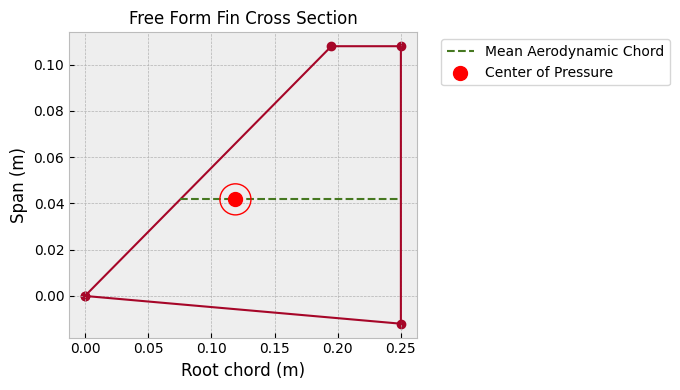

In [40]:
# rocket
rocket_length = rocket_config["total_length"] / 1000
rocket_diameter = rocket_config["rocket"]["diameter"] / 1000
rocket_thickness = rocket_config["rocket"]["thickness"] / 1000


nosecone_length = (
    rocket_config["nosecone"]["length"] - 100
) / 1000  # -100 mm to adjust for cylindrical section
nosecone_kind = rocket_config["nosecone"]["kind"]

nose_cone = NoseCone(
    length=nosecone_length, base_radius=rocket_diameter / 2, kind=nosecone_kind
)

tailcone_cylindrical = rocket_config["tailcone"]["cylindrical_height"] / 1000
tailcone_length = rocket_config["tailcone"]["length"] / 1000
tailcone_bottom_radius = rocket_config["tailcone"]["diameter"] / 2 / 1000

tail = Tail(
    top_radius=rocket_diameter / 2,
    bottom_radius=tailcone_bottom_radius,
    length=tailcone_length,
    rocket_radius=rocket_diameter / 2,
)

fin_amount = rocket_config["fins"]["amount"]
fin_shape_points = rocket_config["fins"]["shape_points"]
fin_name = rocket_config["fins"]["name"]

fin_set = FreeFormFins(
    n=fin_amount,
    shape_points=fin_shape_points,
    rocket_radius=tailcone_bottom_radius,
    name=fin_name,
)
fin_set.draw()

main_cd_s = rocket_config["parachutes"]["drogue"][
    "cd_s"
]  # main didn't deploy fully, so adding another drogue as approximation
main_trigger = rocket_config["parachutes"]["main"]["trigger"]
main_sampling_rate = rocket_config["parachutes"]["main"]["sampling_rate"]
main_lag = rocket_config["parachutes"]["main"]["lag"]
main_noise = rocket_config["parachutes"]["main"]["noise"]

drogue_cd_s = rocket_config["parachutes"]["drogue"]["cd_s"]
drogue_trigger = rocket_config["parachutes"]["drogue"]["trigger"]
drogue_sampling_rate = rocket_config["parachutes"]["drogue"]["sampling_rate"]
drogue_lag = rocket_config["parachutes"]["drogue"]["lag"]
drogue_noise = rocket_config["parachutes"]["drogue"]["noise"]

parachutes = {}

parachutes[0] = Parachute(
    name="main",
    cd_s=main_cd_s,
    trigger=main_trigger,
    sampling_rate=main_sampling_rate,
    lag=main_lag,
    noise=main_noise,
)

parachutes[1] = Parachute(
    name="drogue",
    cd_s=drogue_cd_s,
    trigger=drogue_trigger,
    sampling_rate=drogue_sampling_rate,
    lag=drogue_lag,
    noise=drogue_noise,
)

### Hedy


Inertia Details

Rocket Mass: 17.200 kg (without motor)
Rocket Dry Mass: 17.200 kg (with unloaded motor)
Rocket Loaded Mass: 25.573 kg
Rocket Structural Mass Ratio: 0.673
Rocket Inertia (with unloaded motor) 11: 16.800 kg*m2
Rocket Inertia (with unloaded motor) 22: 16.800 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.025 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0664 m
Rocket Frontal Area: 0.013851 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.853 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.421 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.138 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Biconvex-Freeform Lift Coefficient Derivative: 6.930/rad
Tail Lift

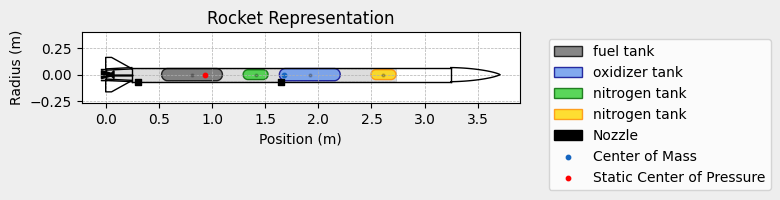


Mass Plots
----------------------------------------


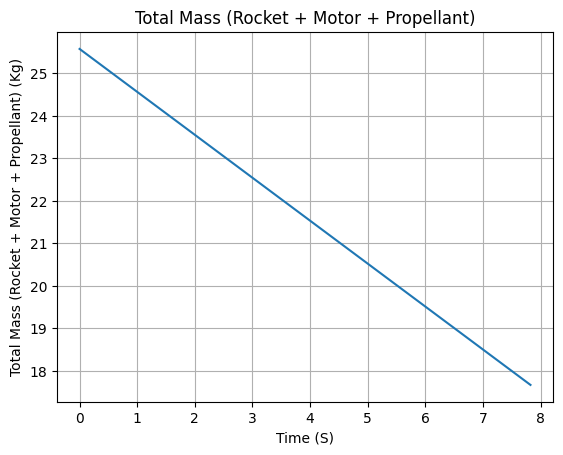

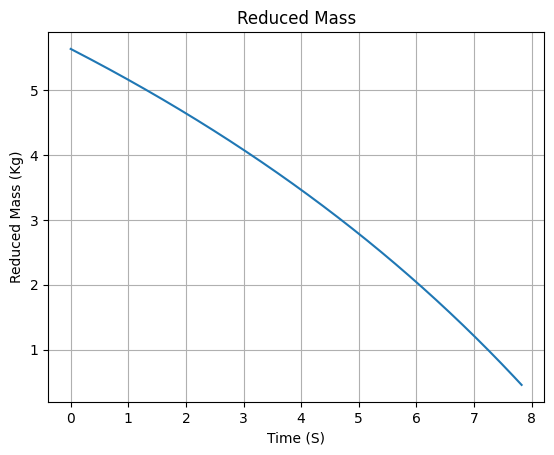


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


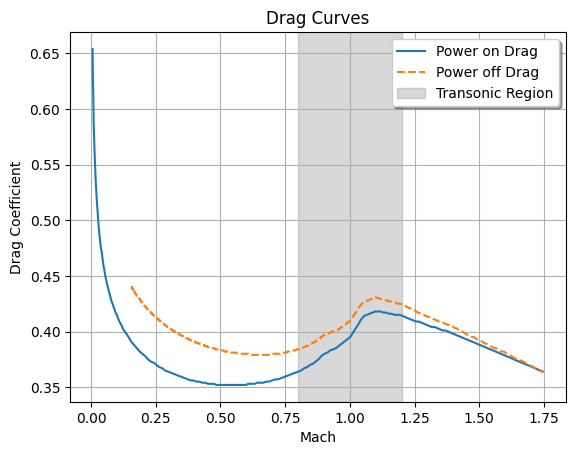


Stability Plots
--------------------


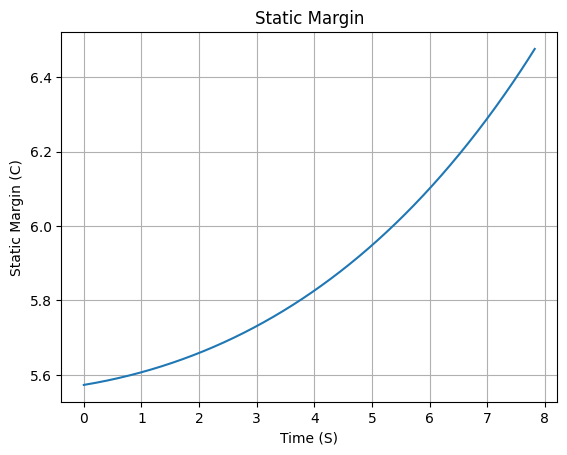

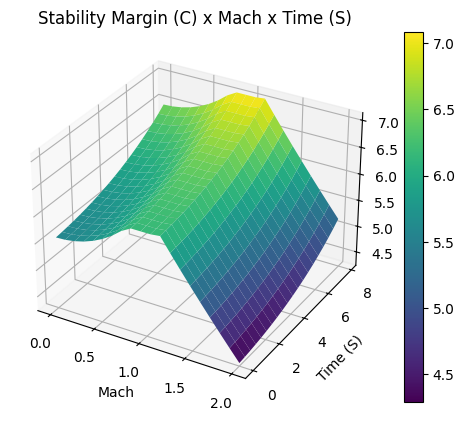


Thrust-to-Weight Plot
----------------------------------------


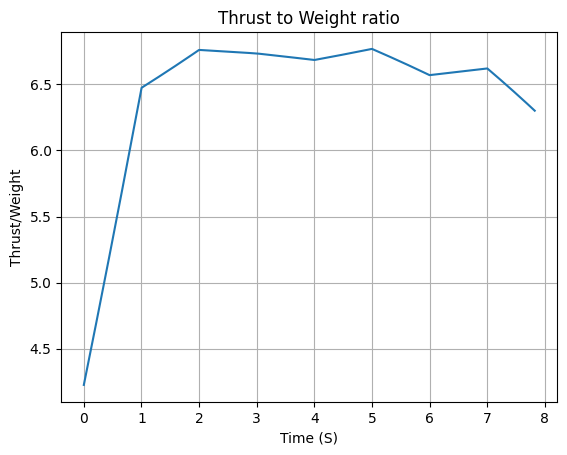

In [41]:
total_mass = rocket_config["total_weight"] / 1000

# inertia
inertia_x_y = rocket_config["moment_of_intertia_XY"]
inertia_z = rocket_config["moment_of_intertia_Z"]

upper_railbutton_position = rocket_config["railbuttons"]["upper"] / 1000
lower_railbutton_position = rocket_config["railbuttons"]["lower"] / 1000
fin_position = rocket_config["fins"]["position"] / 1000
nozzle_position = motor_config["nozzle"]["position"] / 1000

total_CG = rocket_config["total_CG"] / 1000

hedy = Rocket(
    radius=rocket_diameter / 2,
    mass=total_mass,
    inertia=(inertia_x_y, inertia_x_y, inertia_z),
    power_off_drag="../../data/rockets/tust/hedy_power_off_drag.csv",
    power_on_drag="../../data/rockets/tust/hedy_power_on_drag.csv",
    center_of_mass_without_motor=total_CG,
    coordinate_system_orientation="tail_to_nose",
)


hedy.add_motor(skuld, position=nozzle_position)


hedy.set_rail_buttons(
    upper_button_position=upper_railbutton_position,
    lower_button_position=lower_railbutton_position,
)

hedy.add_surfaces(
    surfaces=[nose_cone, fin_set, tail],
    positions=[rocket_length, fin_position, tailcone_length],
)

hedy.parachutes = list(parachutes.values())

hedy.all_info()

### Flight

Takeoff mass: 			 24.85 kg
Propellant used during holddown: 0.72 kg

Rail Departure State

Rail Departure Time: 0.712 s
Rail Departure Velocity: 28.027 m/s
Rail Departure Stability Margin: 5.601 c
Rail Departure Angle of Attack: 4.616°
Rail Departure Thrust-Weight Ratio: 5.807
Rail Departure Reynolds Number: 2.347e+05

Apogee State

Apogee Time: 33.412 s
Apogee Altitude: 5406.918 m (ASL) | 5246.918 m (AGL)
Apogee Freestream Speed: 33.724 m/s
Apogee X position: 419.184 m
Apogee Y position: -1080.044 m
Apogee latitude: 39.3807587°
Apogee longitude: -8.2836624°

Maximum Values

Maximum Speed: 365.662 m/s at 7.83 s
Maximum Mach Number: 1.081 Mach at 7.83 s
Maximum Reynolds Number: 2.810e+06 at 7.83 s
Maximum Dynamic Pressure: 6.857e+04 Pa at 7.83 s
Maximum Acceleration During Motor Burn: 55.421 m/s² at 2.00 s
Maximum Gs During Motor Burn: 5.651 g at 2.00 s
Maximum Acceleration After Motor Burn: 31.722 m/s² at 0.00 s
Maximum Gs After Motor Burn: 3.235 Gs at 0.00 s
Maximum Stability Margin: 

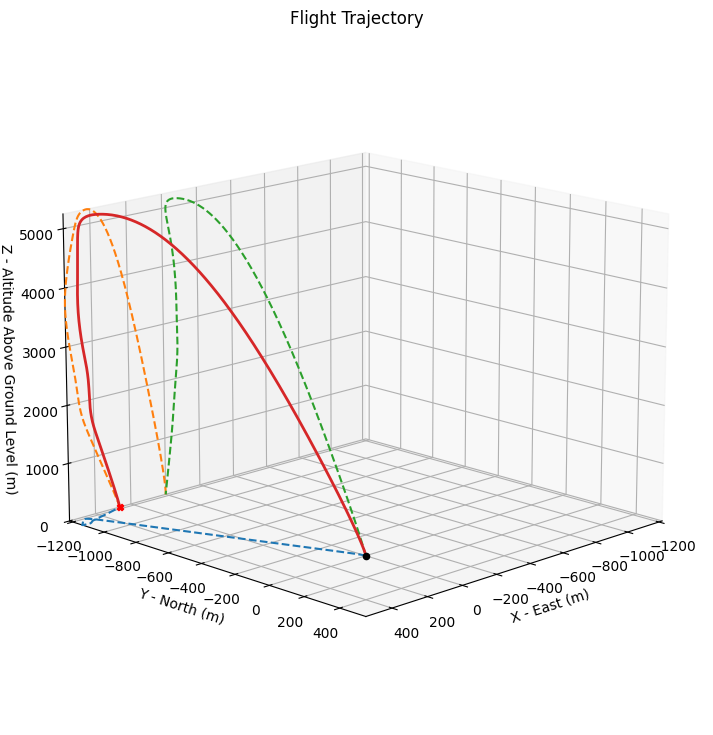

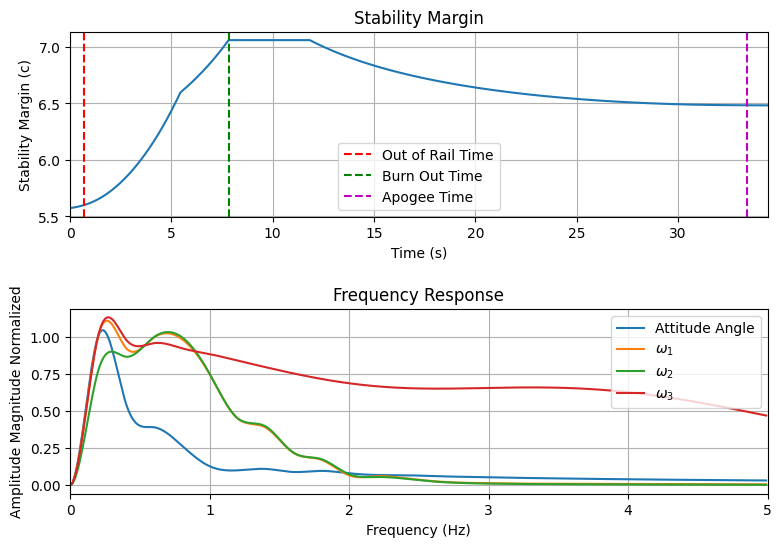

In [42]:
rail_length = flight_config["rail_length"]
inclination = flight_config["inclination"]
heading = flight_config["heading"]
terminate_on_apogee = flight_config["terminate_on_apogee"]

flight_reanalysis = Flight(
    rocket=hedy,
    environment=envReanalysis,
    rail_length=rail_length,
    inclination=inclination,
    heading=heading,
    terminate_on_apogee=terminate_on_apogee,
    name="Reanalysis",
)

print(
    f"Takeoff mass: \t\t\t {hedy.total_mass(flight_reanalysis.out_of_rail_time):.2f} kg"
)
print(
    f"Propellant used during holddown: {hedy.total_mass(0) - hedy.total_mass(flight_reanalysis.out_of_rail_time):.2f} kg"
)

flight_reanalysis.prints.out_of_rail_conditions()
flight_reanalysis.prints.apogee_conditions()
# flight_reanalysis.prints.impact_conditions()
flight_reanalysis.prints.maximum_values()
flight_reanalysis.plots.trajectory_3d()
flight_reanalysis.plots.stability_and_control_data()

# flight_reanalysis.prints.all()
# flight_reanalysis.plots.all()


# flight_reanalysis.all_info()

## Comparsion

### Initialization

In [43]:
from rocketpy import Function
from rocketpy.simulation.flight_data_importer import FlightDataImporter

columns_map_cats_vega = {
    "ts": "time",
    "filteredAltitudeAGL": "altitude",
    "filteredAcceleration": "az",
    "latitude": "latitude",
    "longitude": "longitude",
    "Ax": "acceleration_x",
    "Ay": "acceleration_y",
    "Az": "acceleration_z",
    "Gx": "gyro_x",
    "Gy": "gyro_y",
    "Gz": "gyro_z",
    "velocity": "speed",
    "P": "pressure",
}
path = "../../data/rockets/tust/cats_tust/"

cats_vega_flight = FlightDataImporter(
    name="CATS Vega Flight Data",
    paths=[
        path + "filteredDataInfo.csv",
        path + "gnssInfo.csv",
        path + "flightInfo.csv",
        path + "imu.csv",
        path + "baro.csv",
    ],
    columns_map=columns_map_cats_vega,
    units=None,
    interpolation="linear",
    extrapolation="zero",
    delimiter=",",
    encoding="utf-8",
)

The following attributes were create and are now available to be used:  ['time', 'altitude', 'az']
The following attributes were create and are now available to be used:  ['time', 'latitude', 'longitude']
The following attributes were create and are now available to be used:  ['time', 'speed']
The following attributes were create and are now available to be used:  ['time', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z']
The following attributes were create and are now available to be used:  ['time', 'pressure']


### Altitude

Actual apogee: 5231.53 m
Simulated apogee: 5406.92 m
Error: 175.38 m
Percentage Error: 3.35%


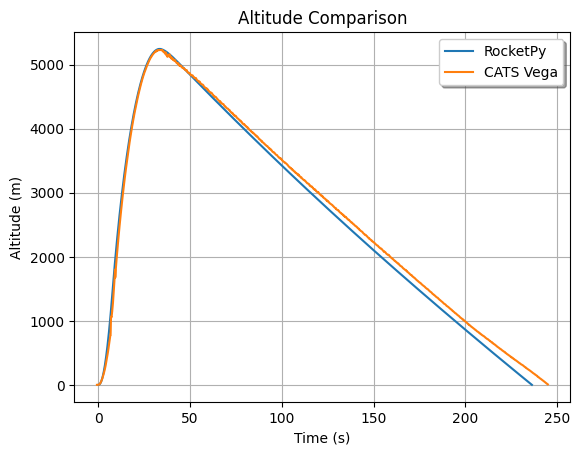

In [44]:
apogee_actual = cats_vega_flight.altitude.max
apogee_simulated = flight_reanalysis.apogee
apogee_error = abs(apogee_actual - apogee_simulated)
apogee_percentage_error = apogee_error / apogee_actual * 100

print(f"Actual apogee: {apogee_actual:.2f} m")
print(f"Simulated apogee: {apogee_simulated:.2f} m")
print(f"Error: {apogee_error:.2f} m")
print(f"Percentage Error: {apogee_percentage_error:.2f}%")


Function.compare_plots(
    [
        (flight_reanalysis.altitude, "RocketPy"),
        (cats_vega_flight.altitude, "CATS Vega"),
    ],
    title="Altitude Comparison",
    xlabel="Time (s)",
    ylabel="Altitude (m)",
)

### GNSS

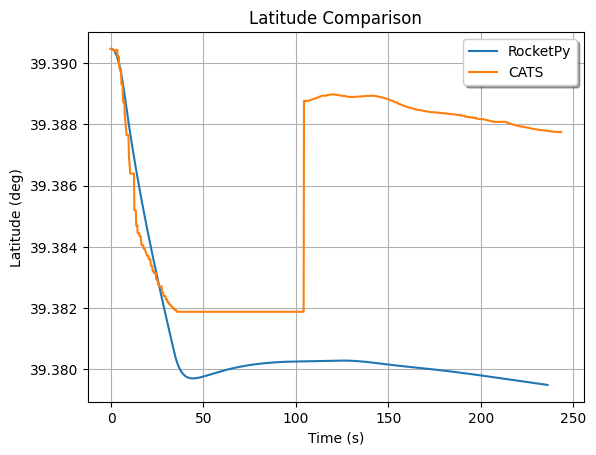

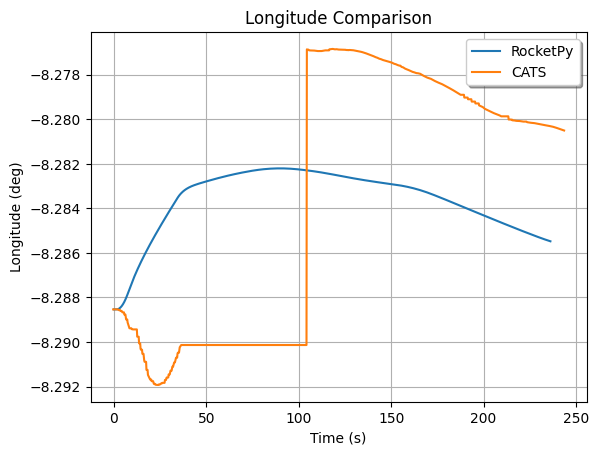

In [45]:
Function.compare_plots(
    [(flight_reanalysis.latitude, "RocketPy"), (cats_vega_flight.latitude, "CATS")],
    title="Latitude Comparison",
    xlabel="Time (s)",
    ylabel="Latitude (deg)",
)
Function.compare_plots(
    [(flight_reanalysis.longitude, "RocketPy"), (cats_vega_flight.longitude, "CATS")],
    title="Longitude Comparison",
    xlabel="Time (s)",
    ylabel="Longitude (deg)",
)

### Pressure

Actual min pressure: 51343.00 Pa
Simulated min pressure: 52452.57 Pa
Error: 1109.57 Pa
Percentage Error: 2.16%


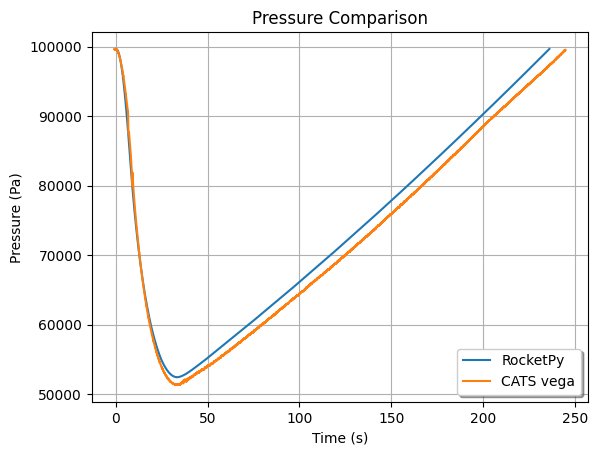

In [46]:
pressure_actual = cats_vega_flight.pressure.min
pressure_simulated = flight_reanalysis.pressure.min
pressure_error = abs(pressure_actual - pressure_simulated)
pressure_percentage_error = pressure_error / pressure_actual * 100

print(f"Actual min pressure: {pressure_actual:.2f} Pa")
print(f"Simulated min pressure: {pressure_simulated:.2f} Pa")
print(f"Error: {pressure_error:.2f} Pa")
print(f"Percentage Error: {pressure_percentage_error:.2f}%")


Function.compare_plots(
    [
        (flight_reanalysis.pressure, "RocketPy"),
        (cats_vega_flight.pressure, "CATS vega"),
    ],
    title="Pressure Comparison",
    xlabel="Time (s)",
    ylabel="Pressure (Pa)",
)

### Acceleration

Actual max acceleration during burn: 56.77 m/s2
Simulated max acceleration during burn: 55.42 m/s2
Error: 1.35 m/s2
Percentage Error: 2.38%


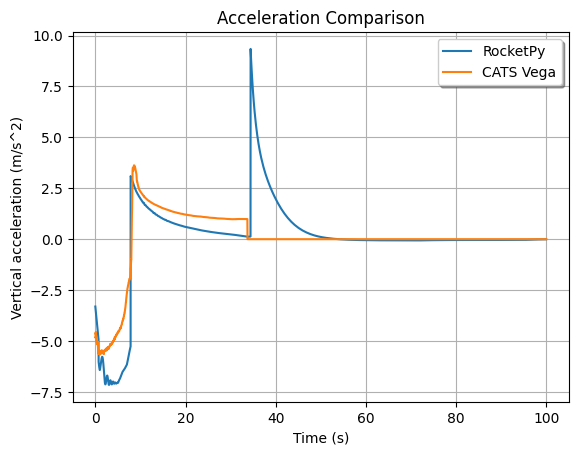

In [47]:
acceleration_actual = cats_vega_flight.az.crop([(0, 20)]).max
acceleration_simulated = flight_reanalysis.acceleration.crop([(0, 20)]).max
acceleration_error = abs(acceleration_actual - acceleration_simulated)
acceleration_percentage_error = acceleration_error / acceleration_actual * 100

print(f"Actual max acceleration during burn: {acceleration_actual:.2f} m/s2")
print(f"Simulated max acceleration during burn: {acceleration_simulated:.2f} m/s2")
print(f"Error: {acceleration_error:.2f} m/s2")
print(f"Percentage Error: {acceleration_percentage_error:.2f}%")

Function.compare_plots(
    [
        (flight_reanalysis.ay.crop([(0, 100)]), "RocketPy"),
        (cats_vega_flight.az.crop([(0, 100)]) / 10 * (-1), "CATS Vega"),
    ],
    title="Acceleration Comparison",
    xlabel="Time (s)",
    ylabel="Vertical acceleration (m/s^2)",
)

### Speed

Actual max speed: 302.54 m/s2
Simulated max speed: 365.66 m/s2
Error: 63.12 m/s2
Percentage Error: 20.86%


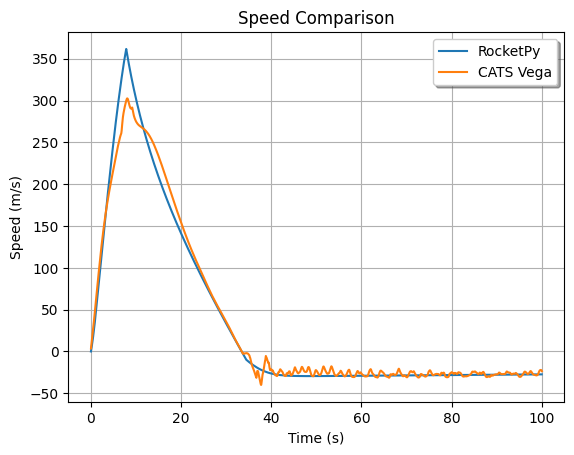

In [48]:
speed_actual = cats_vega_flight.speed.max
speed_simulated = flight_reanalysis.speed.max
speed_error = abs(speed_actual - speed_simulated)
speed_percentage_error = speed_error / speed_actual * 100

print(f"Actual max speed: {speed_actual:.2f} m/s2")
print(f"Simulated max speed: {speed_simulated:.2f} m/s2")
print(f"Error: {speed_error:.2f} m/s2")
print(f"Percentage Error: {speed_percentage_error:.2f}%")

Function.compare_plots(
    [
        (flight_reanalysis.vz.crop([(0, 100)]), "RocketPy"),
        (cats_vega_flight.speed.crop([(0, 100)]), "CATS Vega"),
    ],
    title="Speed Comparison",
    xlabel="Time (s)",
    ylabel="Speed (m/s)",
)